### Import the dependecies

In [209]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle

### Data loading and understanding

In [210]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn (1).csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [211]:
df.shape

(7043, 21)

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [213]:
#Drop the customer id column as it is not important
df=df.drop(columns=["customerID"])
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [214]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [215]:
numerical_col_list=["tenure","MonthlCharges","TotalCharges"]

In [216]:
#Find unique elements in each categorical column of the dataset
for col in df.columns:
  if col not in numerical_col_list:
       print(col,df[col].unique())
       print("-"*50)
    

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [217]:
#change the datatype of TotalCharges column
#df["TotalCharges"]=df["TotalCharges"].astype(float)

In [218]:
len(df[df["TotalCharges"]==" "])

11

In [219]:
df["TotalCharges"]=df["TotalCharges"].replace({" ":"0.0"})

In [220]:
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [221]:
df["TotalCharges"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [222]:
#Checking the distribution of the target column
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


## Initial analysis insights
1. Customer ID removed as it is not important for modelling
2. No Missing values in the dataset
3. Missing Values in the TotalCharges column were replaced with 0
4. Class imbalance identified in the target column

### Exploratory Data Analysis(EDA)

In [223]:
df.shape

(7043, 20)

In [224]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [225]:
df.describe() #Only works in the numerical category

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


#### Numerical Feature Analysis
- Understand the distribution of Numerical Features

In [226]:
def plot_histogram(df,col_name):
    plt.figure(figsize=(5,3))
    sns.histplot(df[col_name],kde=True)
    plt.title(f"Distribution of {col_name}")
     #calculate the mean and meadian for that particular column
    col_mean=df[col_name].mean()
    col_median=df[col_name].median()
     #Add vertical lines for mean and median
    plt.axvline(col_mean,color="Red",linestyle="--",label="Mean")
    plt.axvline(col_median,color="blue",linestyle="-",label="Median")

    plt.legend()

    plt.show()

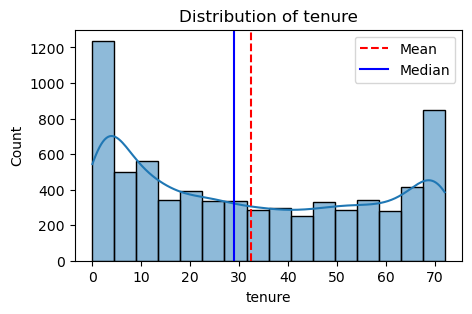

In [227]:
plot_histogram(df,"tenure")

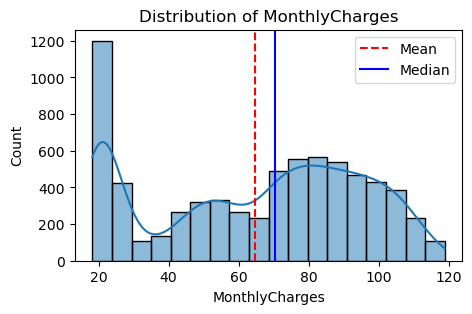

In [228]:
plot_histogram(df,"MonthlyCharges")

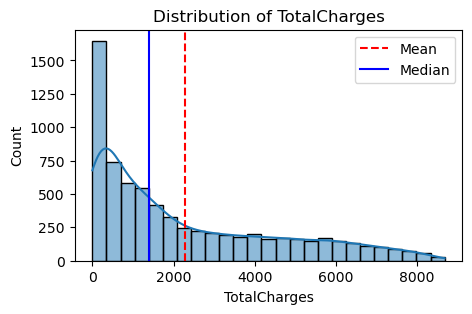

In [229]:
plot_histogram(df,"TotalCharges")

- Boxplot for numerical features 

In [230]:
def plot_boxplot(df,col_name):
    plt.figure(figsize=(5,3))
    sns.boxplot(df[col_name])
    plt.ylabel("col_name")

    plt.show()

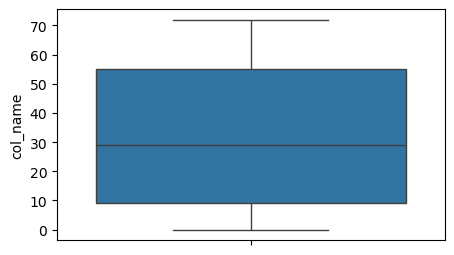

In [231]:
plot_boxplot(df,"tenure")

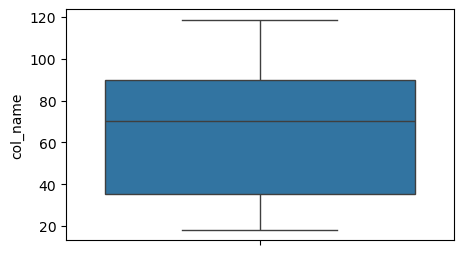

In [232]:
plot_boxplot(df,"MonthlyCharges")

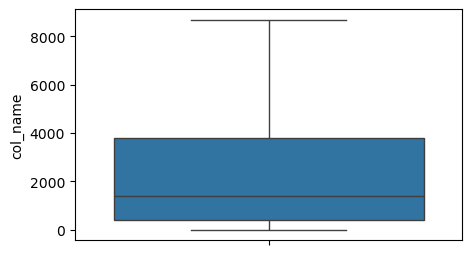

In [233]:
plot_boxplot(df,"TotalCharges")

- Correlation heat map for numerical features

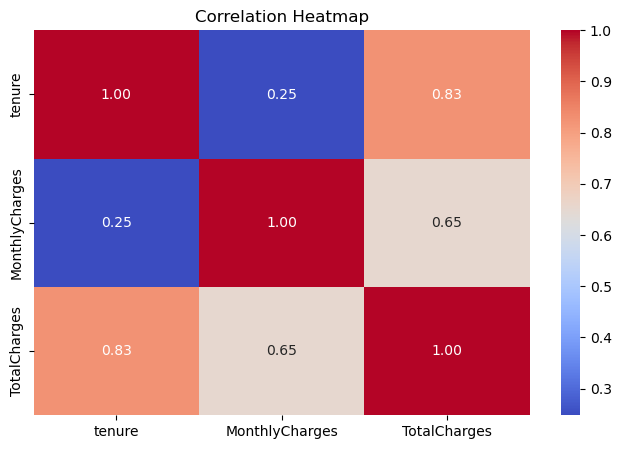

In [234]:
plt.figure(figsize=(8,5))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")

plt.show()

### Categorical Feature Analysis

In [235]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [237]:
#fetch only object columns
object_col=df.select_dtypes(include="object").columns.to_list()
object_col=["SeniorCitizen"]+object_col
object_col

['SeniorCitizen',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

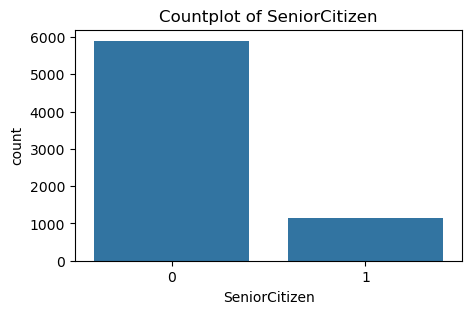

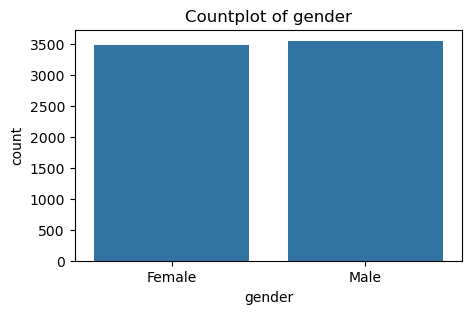

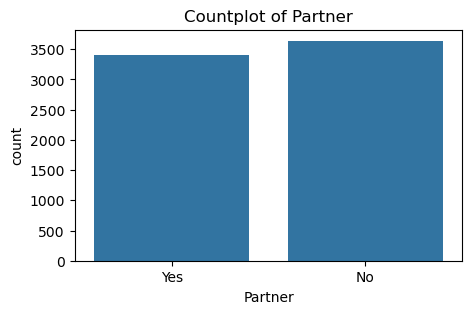

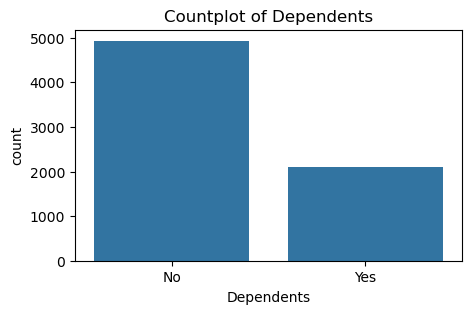

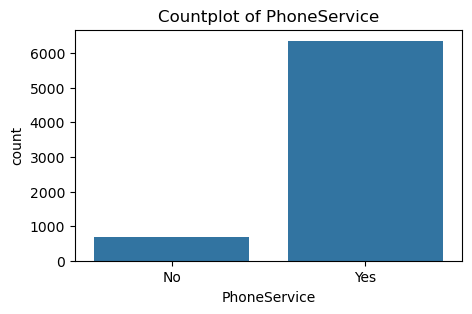

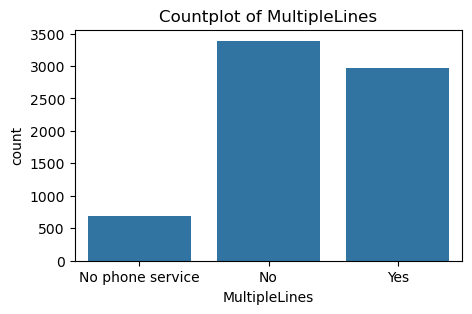

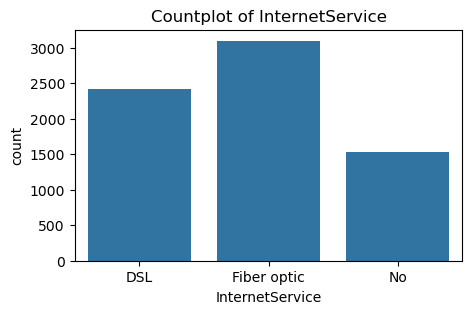

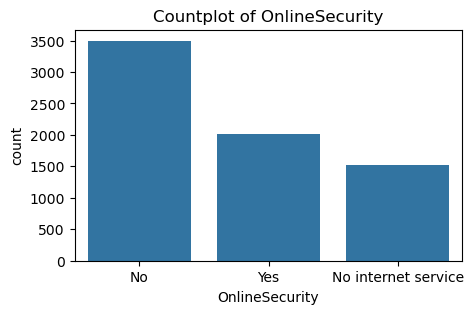

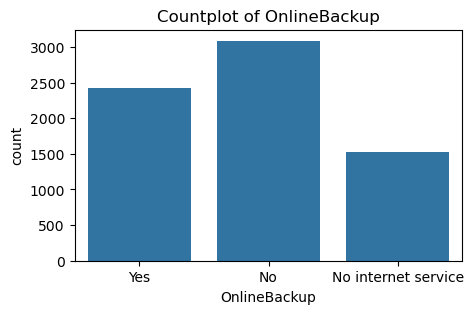

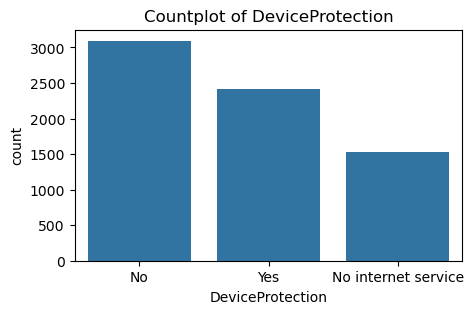

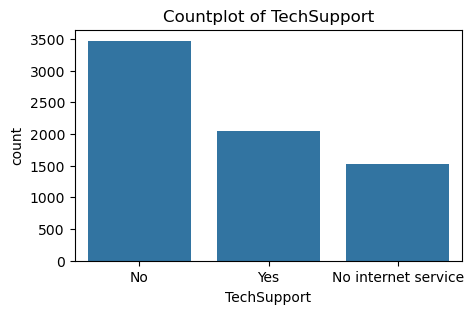

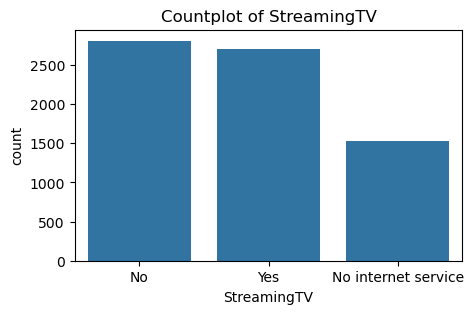

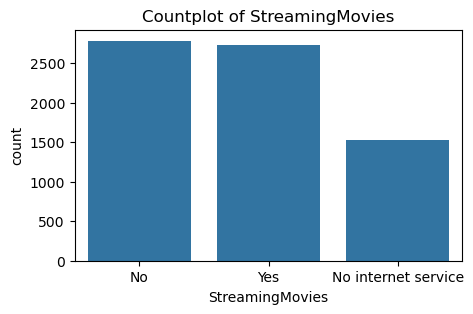

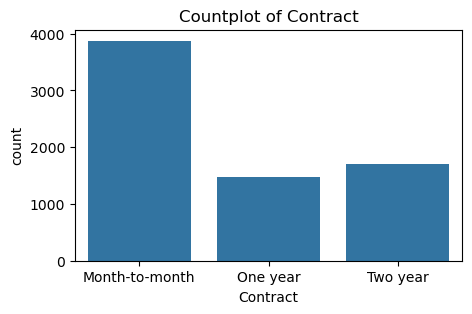

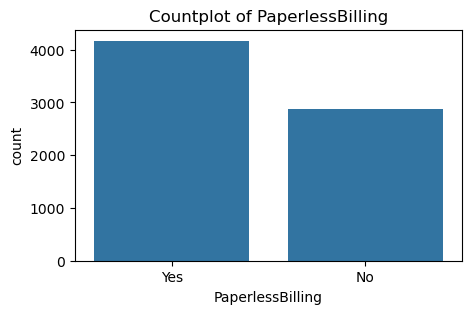

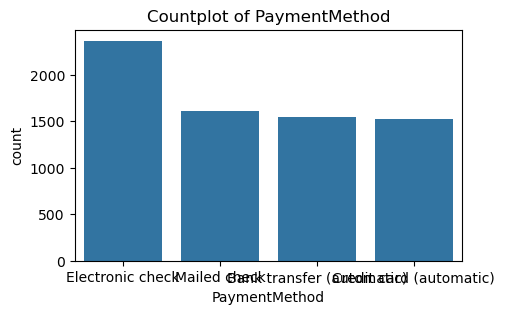

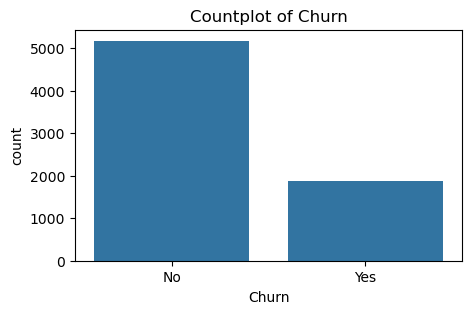

In [238]:
for col in object_col:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.show()

### Data Preprocessing

In [239]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [240]:
## Lebel encode the target column
df["Churn"]=df["Churn"].replace({"Yes":1,"No":0})
df.head(3)

C:\Users\Arijit PC\AppData\Local\Temp\ipykernel_20948\548646942.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"]=df["Churn"].replace({"Yes":1,"No":0})


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [241]:
object_col=df.select_dtypes(include="object").columns
print(object_col)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [242]:
#initialize a dictionary to save the encoders
encoders={}

#Apply label encoding and store the encoders
for col in object_col:
    label_encoder=LabelEncoder()
    df[col]=label_encoder.fit_transform(df[col])
    encoders[col]=label_encoder
#Save the encoders to a pickle file
with open("encoders.pkl","wb") as f:
    pickle.dump(encoders,f)

In [243]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


### Train test split

In [244]:
X=df.drop(columns=["Churn"])
y=df["Churn"]

In [245]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [246]:
print(y_train.value_counts()) #training dataset is not balanced which leads the model of biasness

Churn
0    4138
1    1496
Name: count, dtype: int64


### Synthetic Minority Over sampling technique(SMOT)

In [247]:
smote=SMOTE()
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

In [248]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


### Model training

In [249]:
#dictionary of models
models={
    "DecisionTree":DecisionTreeClassifier(random_state=42),
    "RandomForest":RandomForestClassifier(random_state=42),
    "XGBOOST":XGBClassifier(random_state=42)
}


In [265]:
#dictionary to store the cross validation results
cv_scores={}

#Now perform 10 fold cross avalidation for each model
for model_name,model in models.items():
    print(f"Training  {model_name} with default parameters")
    scores=cross_val_score(model,X_train_smote,y_train_smote,cv=10,scoring="accuracy")
    cv_scores[model_name]=scores
    print(f"{model_name} cross-validation-accuracy: {np.mean(scores):.2f}")
    print("-"*50)

Training  DecisionTree with default parameters
DecisionTree cross-validation-accuracy: 0.79
--------------------------------------------------
Training  RandomForest with default parameters
RandomForest cross-validation-accuracy: 0.85
--------------------------------------------------
Training  XGBOOST with default parameters
XGBOOST cross-validation-accuracy: 0.84
--------------------------------------------------


### Hyperparameter tuning of Random Forest Classifier

In [264]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_tuning = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='precision',
    random_state=42,
    n_jobs=-1
)

rf_tuning.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(rf_tuning.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [251]:
print(cv_scores)

{'DecisionTree': array([0.7089372 , 0.64975845, 0.70772947, 0.76811594, 0.83574879,
       0.85386473, 0.82950423, 0.8331318 , 0.84038694, 0.85126965]), 'RandomForest': array([0.75      , 0.73188406, 0.72342995, 0.81884058, 0.91183575,
       0.91425121, 0.89600967, 0.90568319, 0.90084643, 0.91535671]), 'XGBOOST': array([0.72463768, 0.71376812, 0.70652174, 0.8115942 , 0.91304348,
       0.90338164, 0.88754534, 0.90931076, 0.89842805, 0.90810157])}


Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


### Random Forest gives the highest accuracy compared to other models with default parameters

In [253]:
rfc=RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote,y_train_smote)

RandomForestClassifier(random_state=42)

In [254]:
#Evaluation on test data
y_test_pred=rfc.predict(X_test)

print("Accuracy Score: \n",accuracy_score(y_test,y_test_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_test_pred))
print("CLassification Report: \n",classification_report(y_test,y_test_pred))

Accuracy Score: 
 0.7792760823278921
Confusion Matrix: 
 [[879 157]
 [154 219]]
CLassification Report: 
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.59      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [255]:
#After doing hyperparameter tuning the best rfc is this
best_rfc = rf_tuning.best_estimator_

In [256]:
y_test_pred_tuned = best_rfc.predict(X_test)

print("Accuracy Score: \n", accuracy_score(y_test, y_test_pred_tuned))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_test_pred_tuned))
print("Classification Report: \n", classification_report(y_test, y_test_pred_tuned))

Accuracy Score: 
 0.7835344215755855
Confusion Matrix: 
 [[870 166]
 [139 234]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      1036
           1       0.58      0.63      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.79      1409



In [257]:
#save the trained model into a pickel file
model_data={
    "model":best_rfc,
    "feature_names":X.columns.tolist()
}

with open("Customer_churn_model.pkl","wb") as f:
    pickle.dump(model_data,f)

### Load the saved model and build the predictive system

In [258]:
with open("Customer_churn_model.pkl","rb") as f:
    model_data=pickle.load(f)

loaded_model=model_data["model"]
feature_names=model_data["feature_names"]

In [259]:
print(loaded_model)

RandomForestClassifier(max_depth=20, min_samples_split=5, random_state=42)


In [260]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [261]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}
input_data_df=pd.DataFrame([input_data])
with open("encoders.pkl","rb") as f:
    encoders=pickle.load(f)
    #encode categorical features using the saved encoders
    for column,encoder in encoders.items():
        input_data_df[column]=encoder.transform(input_data_df[column])



In [262]:
print(input_data_df.head(2))

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   

   PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  
0                 1              2           29.85         29.85  


In [263]:
 #make a prediction
prediction=loaded_model.predict(input_data_df)
pred_prob=loaded_model.predict_proba(input_data_df)
print(prediction)

#results
print(f"Prediction: {'Churn' if prediction[0]==1 else 'No Churn'}")
print(f"Prediction Probability: {pred_prob}")

[0]
Prediction: No Churn
Prediction Probability: [[0.63395635 0.36604365]]


## SQL Business Analysis and Business Insights

In [266]:
import sqlite3

In [267]:
conn = sqlite3.connect("customer_churn.db")

df.to_sql(
    "customer_churn",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully!")

Database created successfully!


In [268]:
query = """
SELECT *
FROM customer_churn
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
5,0,0,0,0,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
6,1,0,0,1,22,1,2,1,0,2,0,0,2,0,0,1,1,89.10,1949.40,0
7,0,0,0,0,10,0,1,0,2,0,0,0,0,0,0,0,3,29.75,301.90,0
8,0,0,1,0,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
9,1,0,0,1,62,1,0,0,2,2,0,0,0,0,1,0,0,56.15,3487.95,0


## Business Question 1: What is the overall customer churn rate?

The objective is to determine what percentage of the total customer base has churned.
This gives the business an overall understanding of the severity of the customer retention problem.

In [269]:
query1 = """
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 1 THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate_percentage
FROM customer_churn;
"""

In [270]:
result1 = pd.read_sql_query(query1, conn)

result1

,total_customers,churned_customers,churn_rate_percentage
0,7043,1869,26.54


### Business Insight

The analysis shows that approximately **26.54% of customers have churned**.
This indicates that customer churn is a significant business concern and that
the company needs to focus on improving customer retention.

### Recommendation

The company should prioritize customer retention initiatives and identify
the customer segments that are most vulnerable to churn. Further analysis
should focus on factors such as contract type, tenure, monthly charges,
internet service, and payment method to determine the major drivers of churn.

## Business Question 2: Which contract type has the highest churn rate?

The objective is to compare customer churn across different contract types
and identify the contract segment with the highest churn rate.

In [274]:
query2 = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 1 THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate_percentage
FROM customer_churn
GROUP BY Contract
ORDER BY churn_rate_percentage DESC;
"""

In [275]:
result2 = pd.read_sql_query(query2, conn)

result2

,Contract,total_customers,churned_customers,churn_rate_percentage
0,0,3875,1655,42.71
1,1,1473,166,11.27
2,2,1695,48,2.83


### Business Insight

The analysis shows that **contract type of 0** customers have the highest
churn rate at approximately **42.71%**. This indicates that customers in this
contract segment are more likely to leave compared with customers on other
contract types.

### Recommendation

The company should prioritize retention strategies for the contract segment
with the highest churn rate. For high-risk customers in this segment, the
company could offer personalized discounts, loyalty benefits, or incentives
to encourage longer-term contracts.

## Business Question 3: How does customer tenure affect churn?

The objective is to analyze the relationship between customer tenure and churn
and identify which tenure groups are most likely to leave the company.

In [276]:
query3 = """
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-1 Year'
        WHEN tenure <= 24 THEN '1-2 Years'
        WHEN tenure <= 48 THEN '2-4 Years'
        ELSE '4+ Years'
    END AS tenure_group,

    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 1 THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 * SUM(
            CASE WHEN Churn = 1 THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS churn_rate_percentage

FROM customer_churn

GROUP BY
    CASE
        WHEN tenure <= 12 THEN '0-1 Year'
        WHEN tenure <= 24 THEN '1-2 Years'
        WHEN tenure <= 48 THEN '2-4 Years'
        ELSE '4+ Years'
    END

ORDER BY churn_rate_percentage DESC;
"""

In [277]:
result3 = pd.read_sql_query(query3, conn)

result3

,tenure_group,total_customers,churned_customers,churn_rate_percentage
0,0-1 Year,2186,1037,47.44
1,1-2 Years,1024,294,28.71
2,2-4 Years,1594,325,20.39
3,4+ Years,2239,213,9.51


### Business Insight

The analysis shows that customers in the **highest-churn tenure group**
have the highest churn rate at approximately **47.44%**.

This indicates that customer tenure has an important relationship with
churn, with **newly acquired customers being significantly more likely to churn than long-term customers**.

### Recommendation

The company should prioritize **early-stage customer retention** by strengthening
onboarding, engagement, and personalized support during the first year. Targeted
offers and proactive communication should be used to reduce early customer
attrition and improve long-term customer retention.

## Business Question 4: Does monthly charges influence customer churn?

The objective is to analyze whether customers with higher monthly charges
have a higher churn rate and identify the customer segments that may require
pricing or value-based retention strategies.

In [278]:
query4 = """
SELECT
    CASE
        WHEN MonthlyCharges <= 30 THEN 'Low (<= $30)'
        WHEN MonthlyCharges <= 60 THEN 'Medium ($30-$60)'
        WHEN MonthlyCharges <= 90 THEN 'High ($60-$90)'
        ELSE 'Very High (> $90)'
    END AS monthly_charge_group,

    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 1 THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 * SUM(
            CASE WHEN Churn = 1 THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS churn_rate_percentage

FROM customer_churn

GROUP BY
    CASE
        WHEN MonthlyCharges <= 30 THEN 'Low (<= $30)'
        WHEN MonthlyCharges <= 60 THEN 'Medium ($30-$60)'
        WHEN MonthlyCharges <= 90 THEN 'High ($60-$90)'
        ELSE 'Very High (> $90)'
    END

ORDER BY churn_rate_percentage DESC;
"""

In [279]:
result4 = pd.read_sql_query(query4, conn)

result4

,monthly_charge_group,total_customers,churned_customers,churn_rate_percentage
0,High ($60-$90),2386,809,33.91
1,Very High (> $90),1739,570,32.78
2,Medium ($30-$60),1265,328,25.93
3,Low (<= $30),1653,162,9.80


### Business Insight

The analysis shows that customers in the **High ($60-$90) monthly charge group**
have the highest churn rate at approximately **33.91%**.

This indicates that **higher monthly charges are associated with increased
customer churn**, with customers paying **$60-$90 per month** showing the
greatest vulnerability to churn.

### Recommendation

The company should review the **pricing and perceived value** offered to
customers in the $60-$90 monthly charge segment. Personalized discounts,
value-added service bundles, and targeted retention offers could be used to
reduce churn while maintaining customer revenue.

## Business Question 5: How much monthly revenue is at risk from churned customers?

The objective is to estimate the monthly revenue associated with customers
who have already churned. This helps quantify the financial impact of
customer churn on the business.

In [280]:
query5 = """
SELECT
    COUNT(*) AS churned_customers,
    ROUND(SUM(MonthlyCharges), 2) AS monthly_revenue_lost,
    ROUND(AVG(MonthlyCharges), 2) AS average_monthly_charge
FROM customer_churn
WHERE Churn = 1;
"""

In [281]:
result5 = pd.read_sql_query(query5, conn)

result5

,churned_customers,monthly_revenue_lost,average_monthly_charge
0,1869,139130.85,74.44


### Business Insight

The analysis shows that **1,869 customers have churned**, resulting in an
estimated **USD 139,130.85 in monthly recurring revenue loss**. The average
monthly charge among churned customers is approximately **USD 74.44**.

This highlights that customer churn has a significant direct financial impact
on the business, making customer retention an important revenue-protection
strategy.

### Recommendation

The company should prioritize retention strategies for customers who have a
high probability of churning, particularly those contributing significant
monthly revenue. Proactive customer engagement, personalized retention
offers, and targeted incentives can help reduce recurring revenue loss and
improve long-term customer value.

## Business Question 6: Which contract type has the highest monthly revenue at risk?

The objective is to identify which contract segment contributes the greatest
monthly revenue loss from churned customers. This helps the business
prioritize retention efforts based on financial impact.

In [282]:
query6 = """
SELECT
    Contract,

    COUNT(*) AS churned_customers,

    ROUND(SUM(MonthlyCharges), 2) AS monthly_revenue_at_risk,

    ROUND(AVG(MonthlyCharges), 2) AS average_monthly_charge

FROM customer_churn

WHERE Churn = 1

GROUP BY Contract

ORDER BY monthly_revenue_at_risk DESC;
"""

In [283]:
result6 = pd.read_sql_query(query6, conn)

result6

,Contract,churned_customers,monthly_revenue_at_risk,average_monthly_charge
0,0,1655,120847.10,73.02
1,1,166,14118.45,85.05
2,2,48,4165.30,86.78


### Business Insight

The analysis shows that the **Month-to-month contract segment** contributes
the highest monthly revenue at risk, with approximately **USD 120,847.10**
associated with churned customers.

Although only 166 customers with one-year contracts and 48 customers with
two-year contracts churned, the month-to-month segment accounts for the
majority of the revenue at risk due to its significantly higher number of
churned customers.

This indicates that **month-to-month customers represent the most important
contract segment for revenue-protection efforts**.

### Recommendation

The company should prioritize retention strategies for **month-to-month
customers**, particularly by encouraging them to move to longer-term
contracts. Personalized discounts, loyalty benefits, and incentives for
annual or two-year contract upgrades could help reduce churn and protect
recurring revenue.

## Business Question 7: Among customers predicted as high-risk by the ML model, how much revenue is at risk?

The objective is to use the trained Random Forest model to identify customers
who are predicted to churn and estimate the monthly recurring revenue
associated with these high-risk customers.

This helps the business prioritize retention efforts toward customers who
could potentially generate future revenue loss.

In [290]:
# Predict churn for the test customers
test_predictions = best_rfc.predict(X_test)

# Create a dataframe containing the test customers
risk_data = X_test.copy()

# Add predictions
risk_data['Predicted_Churn'] = test_predictions

risk_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Predicted_Churn
185,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,2,24.80,24.80,1
2715,1,0,0,0,41,1,2,2,1,1,1,1,1,1,0,1,0,25.25,996.45,0
3825,0,0,1,1,52,1,0,2,1,1,1,1,1,1,2,0,3,19.35,1031.70,0
1807,0,0,0,0,1,1,0,1,0,0,2,0,0,0,0,0,2,76.35,76.35,1
132,1,0,0,0,67,1,0,0,0,0,0,2,0,0,2,0,0,50.55,3260.10,0


In [291]:
risk_data['MonthlyRevenueAtRisk'] = (
    risk_data['MonthlyCharges'] * risk_data['Predicted_Churn']
)

risk_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Predicted_Churn,MonthlyRevenueAtRisk
185,0,0,1,0,1,0,1,0,0,0,...,0,0,0,0,1,2,24.80,24.80,1,24.80
2715,1,0,0,0,41,1,2,2,1,1,...,1,1,1,0,1,0,25.25,996.45,0,0.00
3825,0,0,1,1,52,1,0,2,1,1,...,1,1,1,2,0,3,19.35,1031.70,0,0.00
1807,0,0,0,0,1,1,0,1,0,0,...,0,0,0,0,0,2,76.35,76.35,1,76.35
132,1,0,0,0,67,1,0,0,0,0,...,2,0,0,2,0,0,50.55,3260.10,0,0.00


In [292]:
risk_data[risk_data['Predicted_Churn'] == 1].shape

(400, 21)

In [293]:
risk_data.to_sql(
    'customer_risk',
    conn,
    if_exists='replace',
    index=False
)

1409

In [294]:
query7 = """
SELECT
    COUNT(*) AS high_risk_customers,

    ROUND(SUM(MonthlyRevenueAtRisk), 2)
        AS potential_monthly_revenue_at_risk,

    ROUND(AVG(MonthlyCharges), 2)
        AS average_monthly_charge

FROM customer_risk

WHERE Predicted_Churn = 1;
"""

In [295]:
result7 = pd.read_sql_query(query7, conn)

result7

,high_risk_customers,potential_monthly_revenue_at_risk,average_monthly_charge
0,400,29929.9,74.82


### Business Insight

The tuned Random Forest model identifies **400 customers as high-risk**
customers who are predicted to churn. These customers represent
approximately **USD 29,929.90 in potential monthly recurring revenue at risk**.

This demonstrates the practical business value of the churn prediction model,
as the company can identify potentially vulnerable customers before they
churn and prioritize them for proactive retention efforts.

### Recommendation

The company should use the ML model as an early-warning system to identify
high-risk customers and prioritize them for proactive retention campaigns.

Customers with higher monthly charges should receive greater attention,
as preventing churn among high-value customers can help protect recurring
revenue and improve long-term customer retention.